In [1]:
# Section 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [2]:
# Section 2 - Load and Inspect
df = pd.read_csv('naijamarket_analysis.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 25)

Column Data Types:
Transaction_ID                        object
Date                          datetime64[ns]
Month                                  int64
Month_Name                            object
Quarter                               object
State                                 object
Platform                              object
Category                              object
Age_Group                             object
Gender                                object
Customer_Segment                      object
Device_Type                           object
Payment_Method                        object
Delivery_Option                       object
Order_Value_NGN                      float64
Quantity                               int64
Total_Value_NGN                      float64
Discount_Pct                           int64
Discount_Amount_NGN                  float64
Final_Value_NGN                      float64
Delivery_Days                          int64
Customer_Satisfac

,Transaction_ID,Date,Month,Month_Name,Quarter,State,Platform,Category,Age_Group,Gender,Customer_Segment,Device_Type,Payment_Method,Delivery_Option,Order_Value_NGN,Quantity,Total_Value_NGN,Discount_Pct,Discount_Amount_NGN,Final_Value_NGN,Delivery_Days,Customer_Satisfaction,Repeat_Purchase_Likelihood,Returned,Platform_Rating
0,NM-10001,2023-02-17,2,Feb,Q1,Abuja,Jumia,Health & Beauty,35-44,Male,Student,Mobile,Card,Same Day,9605.73,1,9605.73,0,0.00,9605.73,1,5,High,0,4.0
1,NM-10002,2023-01-23,1,Jan,Q1,Oyo,Jumia,Sports & Fitness,45-54,Female,Young Professional,Mobile,Transfer,2-3 Days,59459.62,1,59459.62,25,14864.91,44594.71,2,3,High,1,3.7
2,NM-10003,2023-07-06,7,Jul,Q3,Abuja,Jumia,Home & Living,25-34,Male,Young Professional,Tablet,USSD,Same Day,23705.22,1,23705.22,10,2370.52,21334.70,1,5,High,1,4.2
3,NM-10004,2023-10-18,10,Oct,Q4,Kaduna,Amazon Nigeria,Electronics,25-34,Male,Business Owner,Desktop,Card,Standard (5-7 Days),308583.15,1,308583.15,10,30858.31,277724.84,5,2,Low,0,4.8
4,NM-10005,2023-12-15,12,Dec,Q4,Anambra,Konga,Food & Grocery,18-24,Male,Student,Mobile,Wallet,Same Day,11709.68,1,11709.68,5,585.48,11124.20,1,5,High,0,3.8


In [3]:
# Section 3 - Market Overview
print("=" * 60)
print("   NAIJAMARKET INSIGHTS — E-COMMERCE MARKET OVERVIEW")
print("=" * 60)

total_transactions = len(df)
total_value = df['Final_Value_NGN'].sum()
avg_order = df['Final_Value_NGN'].mean()
avg_satisfaction = df['Customer_Satisfaction'].mean()
return_rate = df['Returned'].mean() * 100
avg_delivery = df['Delivery_Days'].mean()
top_platform = df['Platform'].value_counts().index[0]
top_platform_share = df['Platform'].value_counts().iloc[0] / len(df) * 100
top_category = df.groupby('Category')['Final_Value_NGN'].sum().idxmax()
top_state = df.groupby('State')['Final_Value_NGN'].sum().idxmax()
mobile_pct = (df['Device_Type'] == 'Mobile').mean() * 100

print(f"""
MARKET SUMMARY
--------------------------
Total Transactions:     {total_transactions:,}
Total Market Value:     NGN {total_value:,.0f}
Avg Order Value:        NGN {avg_order:,.0f}
Avg Satisfaction:       {avg_satisfaction:.2f} / 5.0
Return Rate:            {return_rate:.1f}%
Avg Delivery Time:      {avg_delivery:.1f} days

PLATFORM INSIGHTS
--------------------------
Top Platform:           {top_platform} ({top_platform_share:.1f}% market share)

CATEGORY & REGION
--------------------------
Top Category by Value:  {top_category}
Top State by Value:     {top_state}

CONSUMER BEHAVIOUR
--------------------------
Mobile Shopping:        {mobile_pct:.1f}% of transactions
""")

print("PLATFORM MARKET SHARE:")
print("-" * 30)
platform_share = df['Platform'].value_counts(normalize=True) * 100
for platform, share in platform_share.items():
    bar = '█' * int(share / 2)
    print(f"{platform:<20} {share:5.1f}% {bar}")
print("=" * 60)

   NAIJAMARKET INSIGHTS — E-COMMERCE MARKET OVERVIEW

MARKET SUMMARY
--------------------------
Total Transactions:     1,000
Total Market Value:     NGN 88,674,320
Avg Order Value:        NGN 88,674
Avg Satisfaction:       3.68 / 5.0
Return Rate:            17.9%
Avg Delivery Time:      2.8 days

PLATFORM INSIGHTS
--------------------------
Top Platform:           Jumia (30.9% market share)

CATEGORY & REGION
--------------------------
Top Category by Value:  Electronics
Top State by Value:     Abuja

CONSUMER BEHAVIOUR
--------------------------
Mobile Shopping:        71.9% of transactions

PLATFORM MARKET SHARE:
------------------------------
Jumia                 30.9% ███████████████
Konga                 18.3% █████████
Jiji                  15.5% ███████
Shoprite Online       10.1% █████
PayPorte               9.2% ████
Amazon Nigeria         7.3% ███
Instagram Shop         4.7% ██
WhatsApp Commerce      4.0% ██


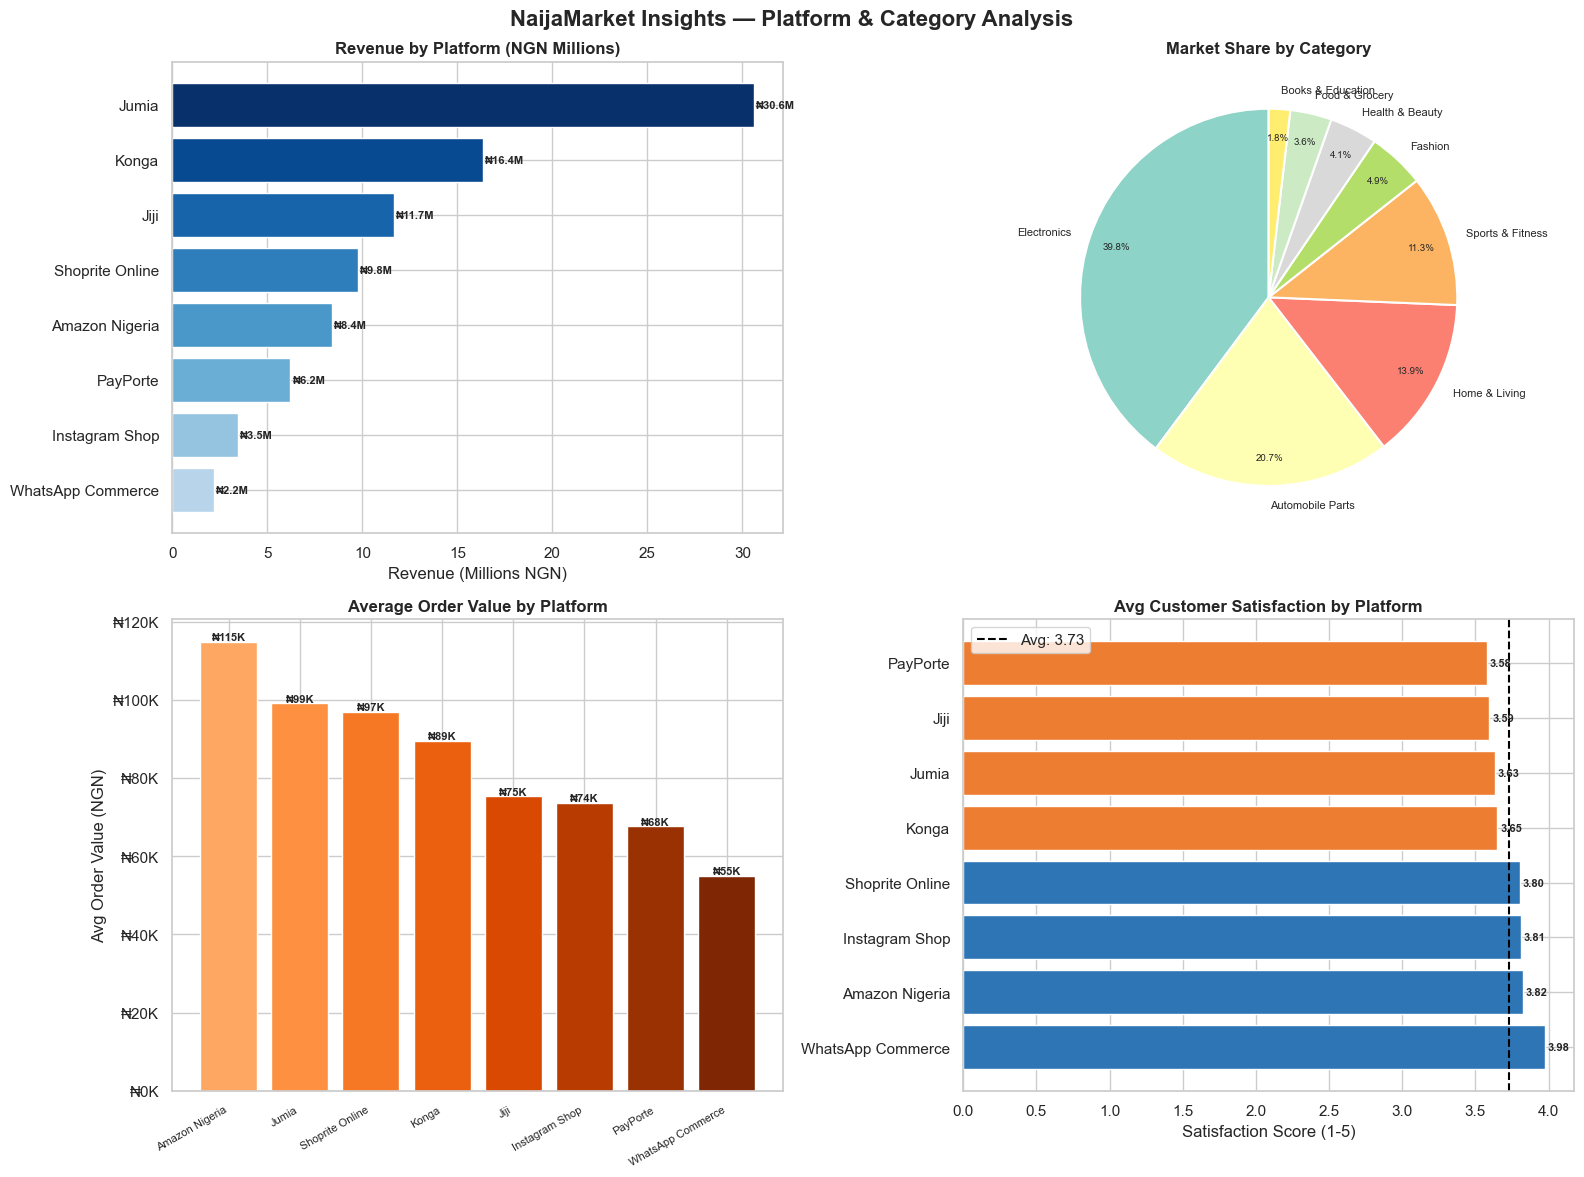

In [4]:
# Section 4 - Platform and Category Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 - Platform Market Share (Horizontal Bar)
platform_revenue = df.groupby('Platform')['Final_Value_NGN'].sum().sort_values()
platform_revenue_M = platform_revenue / 1_000_000
colors_platform = plt.cm.Blues(np.linspace(0.3, 1.0, len(platform_revenue)))
bars = axes[0,0].barh(platform_revenue_M.index, platform_revenue_M.values,
                       color=colors_platform)
axes[0,0].set_title('Revenue by Platform (NGN Millions)', fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Revenue (Millions NGN)')
for bar, val in zip(bars, platform_revenue_M.values):
    axes[0,0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                   f'₦{val:.1f}M', va='center', fontsize=8, fontweight='bold')

# Chart 2 - Category Revenue (Pie Chart)
category_revenue = df.groupby('Category')['Final_Value_NGN'].sum().sort_values(ascending=False)
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(category_revenue)))
wedges, texts, autotexts = axes[0,1].pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    colors=colors_cat,
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in texts: text.set_fontsize(8)
for autotext in autotexts: autotext.set_fontsize(7)
axes[0,1].set_title('Market Share by Category', fontweight='bold', fontsize=12)

# Chart 3 - Platform Average Order Value
platform_aov = df.groupby('Platform')['Final_Value_NGN'].mean().sort_values(ascending=False)
axes[1,0].bar(range(len(platform_aov)), platform_aov.values,
               color=plt.cm.Oranges(np.linspace(0.4, 1.0, len(platform_aov))))
axes[1,0].set_xticks(range(len(platform_aov)))
axes[1,0].set_xticklabels(platform_aov.index, rotation=30, ha='right', fontsize=8)
axes[1,0].set_title('Average Order Value by Platform', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Avg Order Value (NGN)')
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x/1000:.0f}K'))
for i, v in enumerate(platform_aov.values):
    axes[1,0].text(i, v + 500, f'₦{v/1000:.0f}K',
                   ha='center', fontsize=8, fontweight='bold')

# Chart 4 - Customer Satisfaction by Platform
platform_sat = df.groupby('Platform')['Customer_Satisfaction'].mean().sort_values(ascending=False)
colors_sat = ['#2E75B6' if v >= 3.7 else '#ED7D31' if v >= 3.4 else '#C00000'
              for v in platform_sat.values]
axes[1,1].barh(platform_sat.index, platform_sat.values, color=colors_sat)
axes[1,1].set_title('Avg Customer Satisfaction by Platform', fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Satisfaction Score (1-5)')
axes[1,1].axvline(x=platform_sat.mean(), color='black',
                   linestyle='--', label=f'Avg: {platform_sat.mean():.2f}')
axes[1,1].legend()
for i, v in enumerate(platform_sat.values):
    axes[1,1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle('NaijaMarket Insights — Platform & Category Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_platform_category.png', dpi=150, bbox_inches='tight')
plt.show()

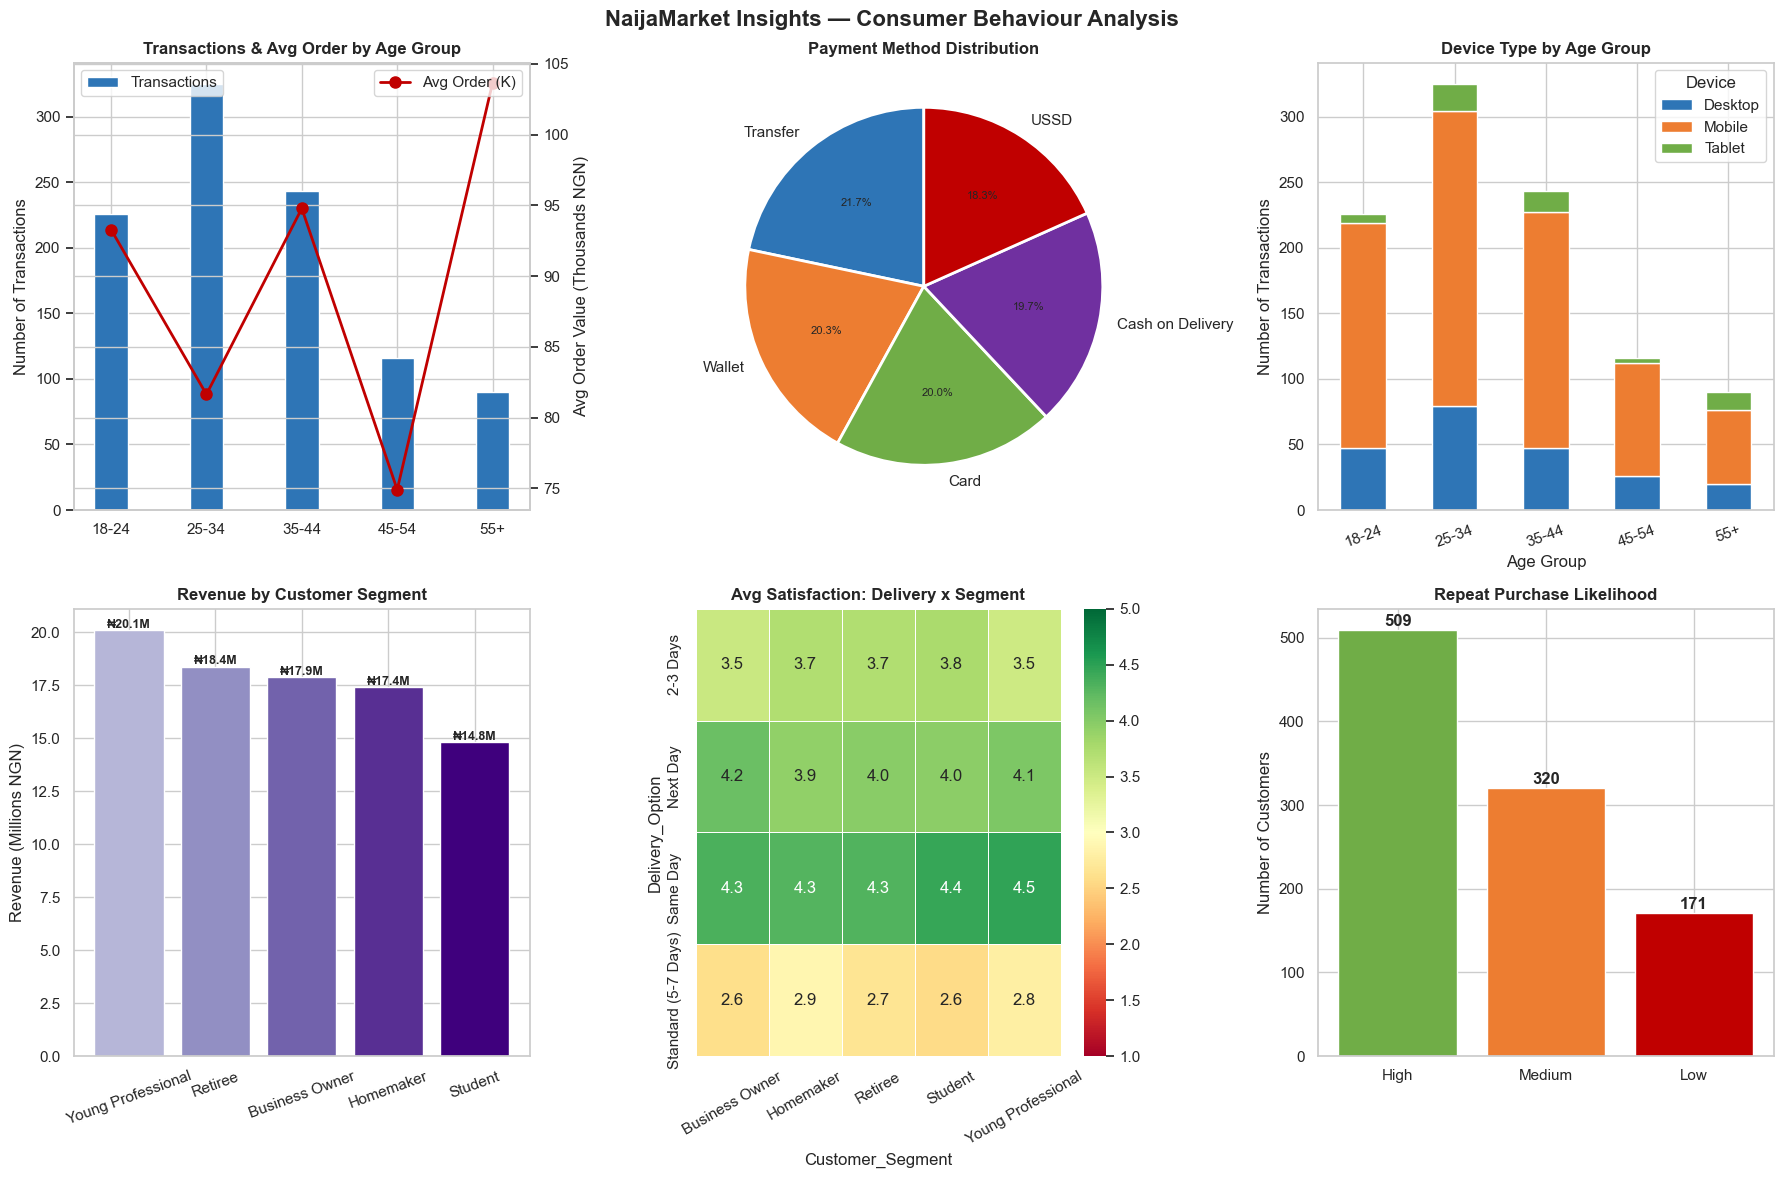

In [5]:
# Section 5 - Consumer Behaviour Analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Chart 1 - Age Group Distribution and Spending
age_data = df.groupby('Age_Group').agg(
    Transactions=('Transaction_ID', 'count'),
    Avg_Order=('Final_Value_NGN', 'mean'),
    Total_Value=('Final_Value_NGN', 'sum')
).reset_index()
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
age_data = age_data.set_index('Age_Group').reindex(age_order).reset_index()

x = np.arange(len(age_data))
width = 0.35
bars1 = axes[0,0].bar(x, age_data['Transactions'], width, 
                       color='#2E75B6', label='Transactions')
ax_twin = axes[0,0].twinx()
ax_twin.plot(x, age_data['Avg_Order']/1000, color='#C00000', 
             marker='o', linewidth=2, markersize=8, label='Avg Order (K)')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(age_data['Age_Group'])
axes[0,0].set_title('Transactions & Avg Order by Age Group', fontweight='bold')
axes[0,0].set_ylabel('Number of Transactions')
ax_twin.set_ylabel('Avg Order Value (Thousands NGN)')
axes[0,0].legend(loc='upper left')
ax_twin.legend(loc='upper right')

# Chart 2 - Payment Method Distribution
payment_counts = df['Payment_Method'].value_counts()
colors_pay = ['#2E75B6', '#ED7D31', '#70AD47', '#7030A0', '#C00000']
wedges, texts, autotexts = axes[0,1].pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=colors_pay,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for autotext in autotexts: autotext.set_fontsize(8)
axes[0,1].set_title('Payment Method Distribution', fontweight='bold')

# Chart 3 - Device Type by Age Group (Stacked Bar)
device_age = df.groupby(['Age_Group', 'Device_Type']).size().unstack(fill_value=0)
device_age = device_age.reindex(age_order)
device_age.plot(kind='bar', stacked=True, ax=axes[0,2],
                color=['#2E75B6', '#ED7D31', '#70AD47'])
axes[0,2].set_title('Device Type by Age Group', fontweight='bold')
axes[0,2].set_xlabel('Age Group')
axes[0,2].set_ylabel('Number of Transactions')
axes[0,2].tick_params(axis='x', rotation=20)
axes[0,2].legend(title='Device', loc='upper right')

# Chart 4 - Customer Segment Revenue
segment_rev = df.groupby('Customer_Segment')['Final_Value_NGN'].sum().sort_values(ascending=False)
segment_rev_M = segment_rev / 1_000_000
axes[1,0].bar(segment_rev_M.index, segment_rev_M.values,
               color=plt.cm.Purples(np.linspace(0.4, 1.0, len(segment_rev_M))))
axes[1,0].set_title('Revenue by Customer Segment', fontweight='bold')
axes[1,0].set_ylabel('Revenue (Millions NGN)')
axes[1,0].tick_params(axis='x', rotation=20)
for i, v in enumerate(segment_rev_M.values):
    axes[1,0].text(i, v + 0.1, f'₦{v:.1f}M', ha='center', fontsize=9, fontweight='bold')

# Chart 5 - Delivery Option Satisfaction Heatmap
delivery_sat = df.groupby(['Delivery_Option', 'Customer_Segment'])['Customer_Satisfaction'].mean().unstack()
sns.heatmap(delivery_sat, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[1,1], vmin=1, vmax=5, linewidths=0.5)
axes[1,1].set_title('Avg Satisfaction: Delivery x Segment', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)

# Chart 6 - Repeat Purchase Likelihood
repeat_data = df['Repeat_Purchase_Likelihood'].value_counts()
order = ['High', 'Medium', 'Low']
repeat_data = repeat_data.reindex(order)
colors_repeat = ['#70AD47', '#ED7D31', '#C00000']
axes[1,2].bar(repeat_data.index, repeat_data.values, color=colors_repeat)
axes[1,2].set_title('Repeat Purchase Likelihood', fontweight='bold')
axes[1,2].set_ylabel('Number of Customers')
for i, v in enumerate(repeat_data.values):
    axes[1,2].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('NaijaMarket Insights — Consumer Behaviour Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_consumer_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

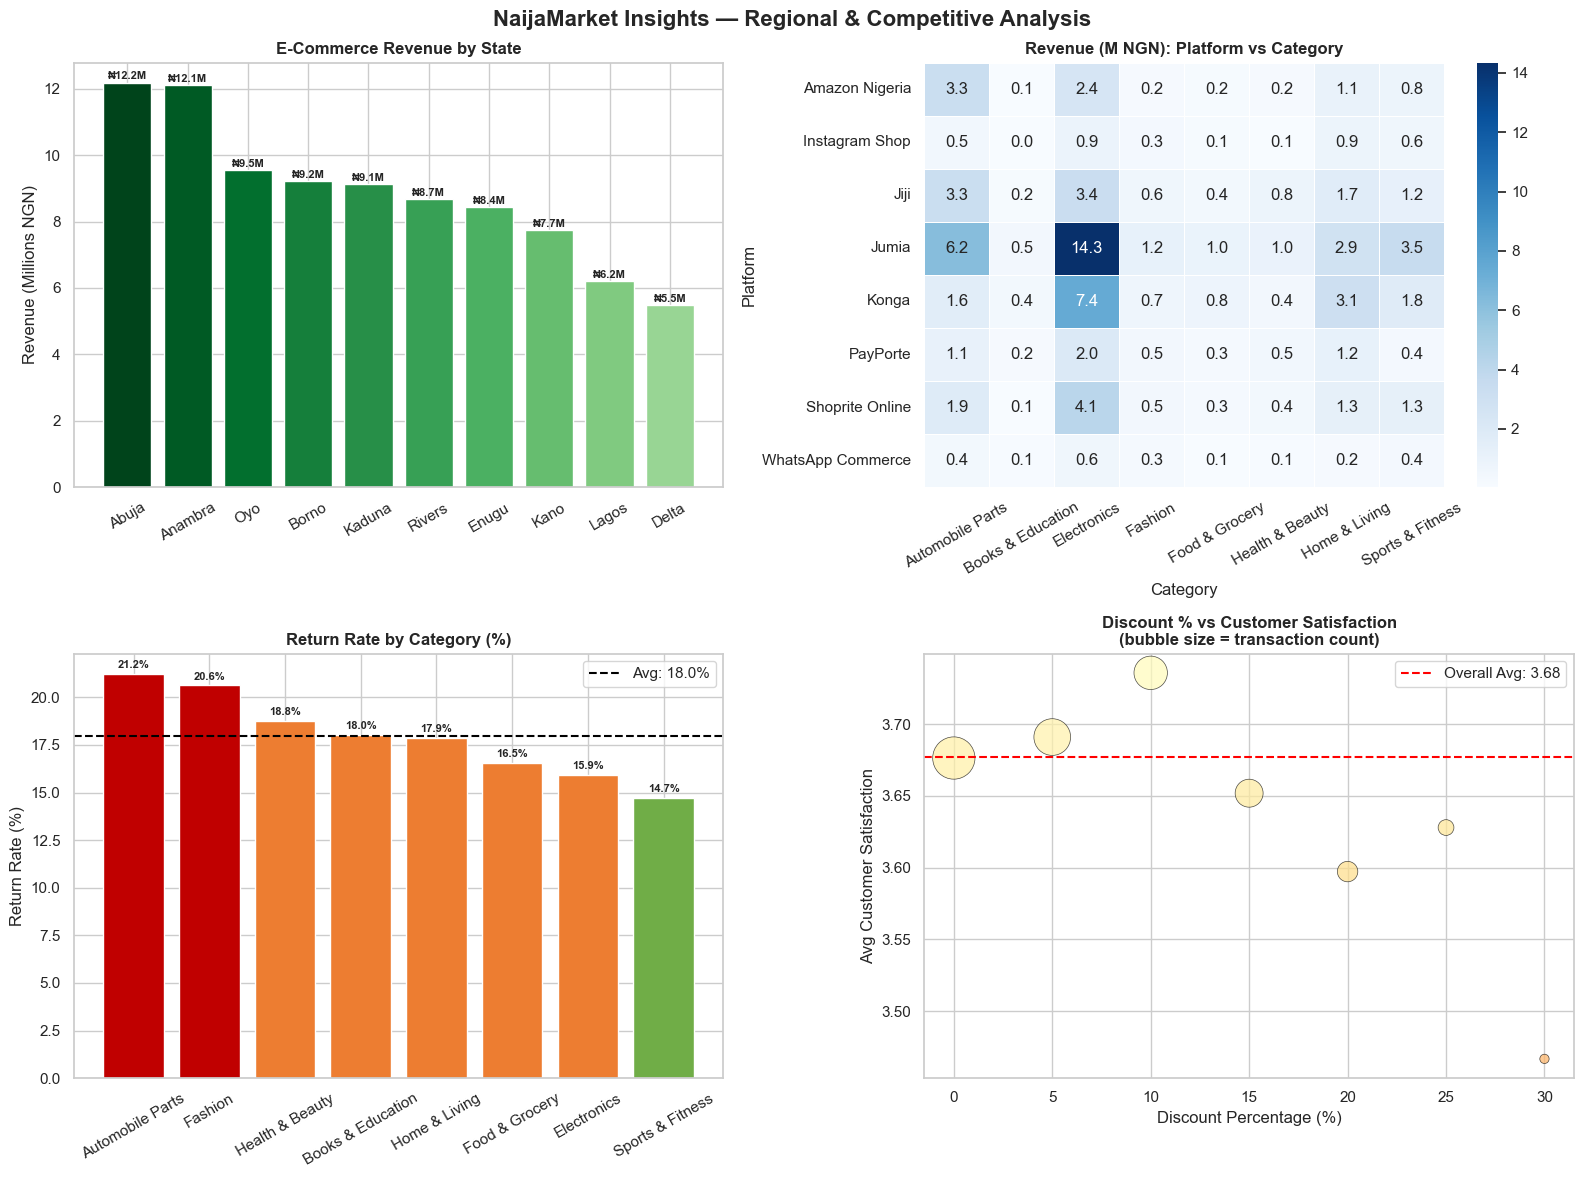

In [6]:
# Section 6 - Regional and Competitive Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 - Revenue by State
state_rev = df.groupby('State')['Final_Value_NGN'].sum().sort_values(ascending=False)
state_rev_M = state_rev / 1_000_000
colors_state = plt.cm.Greens(np.linspace(0.4, 1.0, len(state_rev_M)))
axes[0,0].bar(state_rev_M.index, state_rev_M.values, color=colors_state[::-1])
axes[0,0].set_title('E-Commerce Revenue by State', fontweight='bold')
axes[0,0].set_ylabel('Revenue (Millions NGN)')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(state_rev_M.values):
    axes[0,0].text(i, v + 0.1, f'₦{v:.1f}M', ha='center', fontsize=8, fontweight='bold')

# Chart 2 - Platform vs Category Heatmap
platform_category = df.groupby(['Platform', 'Category'])['Final_Value_NGN'].sum().unstack(fill_value=0)
platform_category_M = platform_category / 1_000_000
sns.heatmap(platform_category_M, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[0,1], linewidths=0.5)
axes[0,1].set_title('Revenue (M NGN): Platform vs Category', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].tick_params(axis='y', rotation=0)

# Chart 3 - Return Rate by Category
return_rate = df.groupby('Category')['Returned'].mean() * 100
return_rate = return_rate.sort_values(ascending=False)
colors_return = ['#C00000' if v > 20 else '#ED7D31' if v > 15 else '#70AD47'
                 for v in return_rate.values]
axes[1,0].bar(return_rate.index, return_rate.values, color=colors_return)
axes[1,0].set_title('Return Rate by Category (%)', fontweight='bold')
axes[1,0].set_ylabel('Return Rate (%)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].axhline(y=return_rate.mean(), color='black', linestyle='--',
                   label=f'Avg: {return_rate.mean():.1f}%')
axes[1,0].legend()
for i, v in enumerate(return_rate.values):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

# Chart 4 - Discount Impact on Satisfaction
discount_sat = df.groupby('Discount_Pct')['Customer_Satisfaction'].mean()
discount_count = df.groupby('Discount_Pct').size()
axes[1,1].scatter(discount_sat.index, discount_sat.values,
                   s=discount_count.values * 3,
                   c=discount_sat.values, cmap='RdYlGn',
                   alpha=0.7, edgecolors='black', linewidths=0.5,
                   vmin=3, vmax=4.5)
axes[1,1].set_title('Discount % vs Customer Satisfaction\n(bubble size = transaction count)',
                     fontweight='bold')
axes[1,1].set_xlabel('Discount Percentage (%)')
axes[1,1].set_ylabel('Avg Customer Satisfaction')
axes[1,1].axhline(y=df['Customer_Satisfaction'].mean(), color='red',
                   linestyle='--', label=f'Overall Avg: {df["Customer_Satisfaction"].mean():.2f}')
axes[1,1].legend()

plt.suptitle('NaijaMarket Insights — Regional & Competitive Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_regional_competitive.png', dpi=150, bbox_inches='tight')
plt.show()

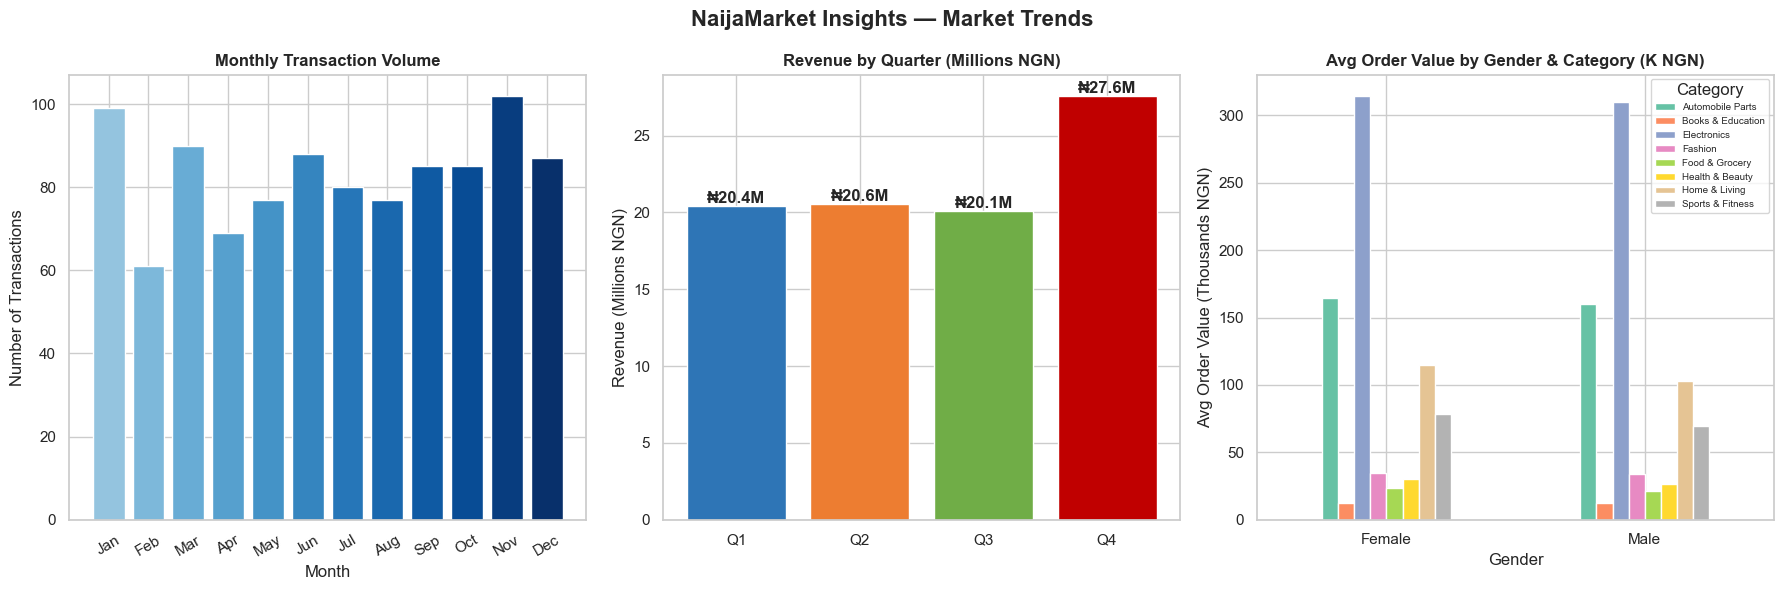

In [7]:
# Section 7 - Market Trends Over Time

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 - Monthly Transaction Volume
monthly_txn = df.groupby('Month_Name').agg(
    Transactions=('Transaction_ID', 'count'),
    Revenue=('Final_Value_NGN', 'sum')
).reset_index()

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_txn['Month_Name'] = pd.Categorical(monthly_txn['Month_Name'],
                                             categories=month_order, ordered=True)
monthly_txn = monthly_txn.sort_values('Month_Name')

axes[0].bar(monthly_txn['Month_Name'], monthly_txn['Transactions'],
             color=plt.cm.Blues(np.linspace(0.4, 1.0, 12)))
axes[0].set_title('Monthly Transaction Volume', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2 - Quarterly Revenue
quarterly_rev = df.groupby('Quarter')['Final_Value_NGN'].sum() / 1_000_000
axes[1].bar(quarterly_rev.index, quarterly_rev.values,
             color=['#2E75B6', '#ED7D31', '#70AD47', '#C00000'])
axes[1].set_title('Revenue by Quarter (Millions NGN)', fontweight='bold')
axes[1].set_ylabel('Revenue (Millions NGN)')
for i, v in enumerate(quarterly_rev.values):
    axes[1].text(i, v + 0.2, f'₦{v:.1f}M', ha='center', fontweight='bold')

# Chart 3 - Gender spending by Category
gender_cat = df.groupby(['Gender', 'Category'])['Final_Value_NGN'].mean().unstack()
gender_cat_K = gender_cat / 1000
gender_cat_K.plot(kind='bar', ax=axes[2],
                   color=plt.cm.Set2(np.linspace(0, 1, len(gender_cat_K.columns))))
axes[2].set_title('Avg Order Value by Gender & Category (K NGN)',
                   fontweight='bold')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Avg Order Value (Thousands NGN)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Category', fontsize=7, loc='upper right')

plt.suptitle('NaijaMarket Insights — Market Trends', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_market_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Section 8 - Final Insights Summary

print("=" * 62)
print("   NAIJAMARKET INSIGHTS — COMPLETE MARKET ANALYSIS")
print("=" * 62)

total_val = df['Final_Value_NGN'].sum()
avg_order = df['Final_Value_NGN'].mean()
top_platform = df['Platform'].value_counts().index[0]
top_platform_pct = df['Platform'].value_counts().iloc[0] / len(df) * 100
top_cat = df.groupby('Category')['Final_Value_NGN'].sum().idxmax()
top_state = df.groupby('State')['Final_Value_NGN'].sum().idxmax()
mobile_pct = (df['Device_Type'] == 'Mobile').mean() * 100
highest_return = df.groupby('Category')['Returned'].mean().idxmax()
highest_return_rate = df.groupby('Category')['Returned'].mean().max() * 100
high_repeat = (df['Repeat_Purchase_Likelihood'] == 'High').mean() * 100
best_delivery = df.groupby('Delivery_Option')['Customer_Satisfaction'].mean().idxmax()

print(f"""
MARKET OVERVIEW
-----------------------------
Total Market Value:       NGN {total_val:,.0f}
Total Transactions:       {len(df):,}
Avg Order Value:          NGN {avg_order:,.0f}
Avg Satisfaction:         {df['Customer_Satisfaction'].mean():.2f} / 5.0
Overall Return Rate:      {df['Returned'].mean()*100:.1f}%

PLATFORM INSIGHTS
-----------------------------
Market Leader:            {top_platform} ({top_platform_pct:.1f}% market share)
Best Satisfaction:        {df.groupby('Platform')['Customer_Satisfaction'].mean().idxmax()}
Highest Avg Order:        {df.groupby('Platform')['Final_Value_NGN'].mean().idxmax()}

CATEGORY INSIGHTS
-----------------------------
Top Category by Revenue:  {top_cat}
Highest Return Rate:      {highest_return} ({highest_return_rate:.1f}%)

CONSUMER BEHAVIOUR
-----------------------------
Mobile Shopping Rate:     {mobile_pct:.1f}%
High Repeat Customers:    {high_repeat:.1f}%
Best Delivery Experience: {best_delivery}
Top State by Revenue:     {top_state}

KEY BUSINESS RECOMMENDATIONS
-----------------------------
1. Jumia dominates but satisfaction scores show room for competitors
2. Electronics drives revenue but has high return rates — improve QC
3. Mobile-first strategy essential — {mobile_pct:.0f}% of transactions on mobile
4. Same-day delivery drives highest satisfaction — invest in logistics
5. Young Professionals (25-34) are the largest and most valuable segment
6. Lagos dominates but Abuja and Rivers show strong growth potential
7. Discount strategy needs review — high discounts not improving satisfaction
""")
print("=" * 62)
print("   PROJECT 5 COMPLETE — PORTFOLIO FULLY BUILT!")
print("=" * 62)

   NAIJAMARKET INSIGHTS — COMPLETE MARKET ANALYSIS

MARKET OVERVIEW
-----------------------------
Total Market Value:       NGN 88,674,320
Total Transactions:       1,000
Avg Order Value:          NGN 88,674
Avg Satisfaction:         3.68 / 5.0
Overall Return Rate:      17.9%

PLATFORM INSIGHTS
-----------------------------
Market Leader:            Jumia (30.9% market share)
Best Satisfaction:        WhatsApp Commerce
Highest Avg Order:        Amazon Nigeria

CATEGORY INSIGHTS
-----------------------------
Top Category by Revenue:  Electronics
Highest Return Rate:      Automobile Parts (21.2%)

CONSUMER BEHAVIOUR
-----------------------------
Mobile Shopping Rate:     71.9%
High Repeat Customers:    50.9%
Best Delivery Experience: Same Day
Top State by Revenue:     Abuja

KEY BUSINESS RECOMMENDATIONS
-----------------------------
1. Jumia dominates but satisfaction scores show room for competitors
2. Electronics drives revenue but has high return rates — improve QC
3. Mobile-first str

In [9]:
# Section 9 - Export for Power BI
df.to_csv('naijamarket_clean.csv', index=False)

# Platform summary
platform_summary = df.groupby('Platform').agg(
    Total_Revenue=('Final_Value_NGN', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Avg_Order=('Final_Value_NGN', 'mean'),
    Avg_Satisfaction=('Customer_Satisfaction', 'mean'),
    Return_Rate=('Returned', 'mean')
).reset_index()
platform_summary.to_csv('platform_summary.csv', index=False)

print("Exported successfully ✅")
print(f"Main dataset: {df.shape}")
print(f"Platform summary: {platform_summary.shape}")

Exported successfully ✅
Main dataset: (1000, 25)
Platform summary: (8, 6)
